# 🍷 Red Wine Quality - Machine Learning Models
## Predictive Modeling & Analysis

---

**Project:** Vino Veritas - Wine Quality Prediction  
**Analyst:** Adam (Data Scientist)  
**Objective:** Build and evaluate machine learning models to predict wine quality and identify key factors

---

### Table of Contents
1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
2. [Data Preprocessing](#2.-Data-Preprocessing)
3. [Feature Engineering](#3.-Feature-Engineering)
4. [Model Building - Classification](#4.-Model-Building---Classification)
5. [Model Building - Regression](#5.-Model-Building---Regression)
6. [Hyperparameter Tuning](#6.-Hyperparameter-Tuning)
7. [Model Comparison & Evaluation](#7.-Model-Comparison-&-Evaluation)
8. [Feature Importance Analysis](#8.-Feature-Importance-Analysis)
9. [Final Model & Predictions](#9.-Final-Model-&-Predictions)
10. [Conclusions & Recommendations](#10.-Conclusions-&-Recommendations)

---
## 1. Setup & Data Loading

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Sklearn - Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Sklearn - Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Sklearn - Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             mean_squared_error, mean_absolute_error, r2_score)

# XGBoost and LightGBM
!pip install xgboost lightgbm -q
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the cleansed dataset from Google Drive
file_path = '/content/drive/My Drive/Wine Quality/winequality_red_cleansed.csv'

# Read the CSV file
df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {list(df.columns)}")

✅ Dataset loaded successfully!
📊 Shape: 985 rows × 12 columns

📋 Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [4]:
# Quick data overview
print("📊 Dataset Overview:")
print("=" * 60)
df.info()
print("\n")
df.head()

📊 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         985 non-null    float64
 1   volatile acidity      985 non-null    float64
 2   citric acid           985 non-null    float64
 3   residual sugar        985 non-null    float64
 4   chlorides             985 non-null    float64
 5   free sulfur dioxide   985 non-null    float64
 6   total sulfur dioxide  985 non-null    float64
 7   density               985 non-null    float64
 8   pH                    985 non-null    float64
 9   sulphates             985 non-null    float64
 10  alcohol               985 non-null    float64
 11  quality               985 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 92.5 KB




,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


🎯 Target Variable (Quality) Distribution:
quality
3      2
4     32
5    415
6    411
7    116
8      9
Name: count, dtype: int64


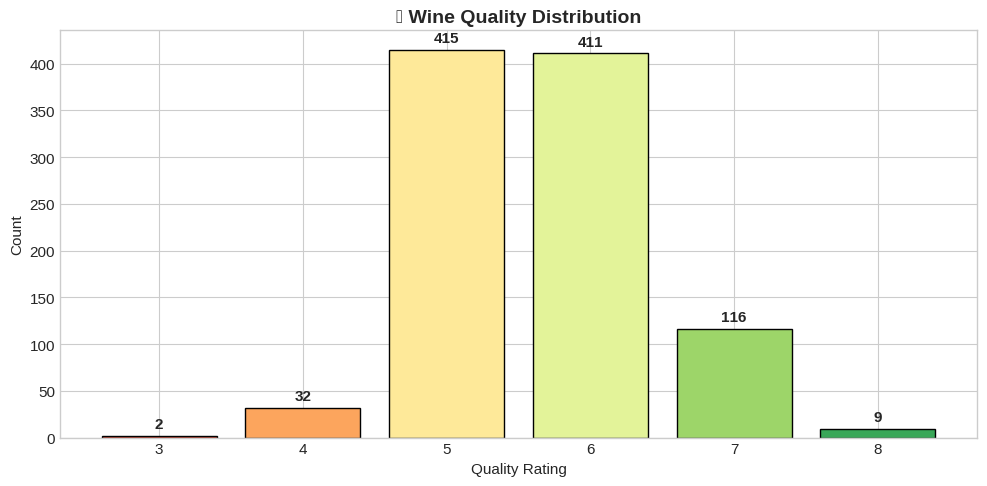

In [5]:
# Target variable distribution
print("🎯 Target Variable (Quality) Distribution:")
print("=" * 60)
print(df['quality'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 5))
quality_counts = df['quality'].value_counts().sort_index()
colors = sns.color_palette('RdYlGn', n_colors=len(quality_counts))
bars = ax.bar(quality_counts.index.astype(str), quality_counts.values, color=colors, edgecolor='black')
ax.set_xlabel('Quality Rating')
ax.set_ylabel('Count')
ax.set_title('🍷 Wine Quality Distribution', fontsize=14, fontweight='bold')

for bar, count in zip(bars, quality_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 2. Data Preprocessing

In [6]:
# Separate features and target
X = df.drop('quality', axis=1)
y = df['quality']

print(f"📊 Features shape: {X.shape}")
print(f"🎯 Target shape: {y.shape}")
print(f"\n📋 Feature names: {list(X.columns)}")

📊 Features shape: (985, 11)
🎯 Target shape: (985,)

📋 Feature names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


🔥 Feature Correlation Heatmap


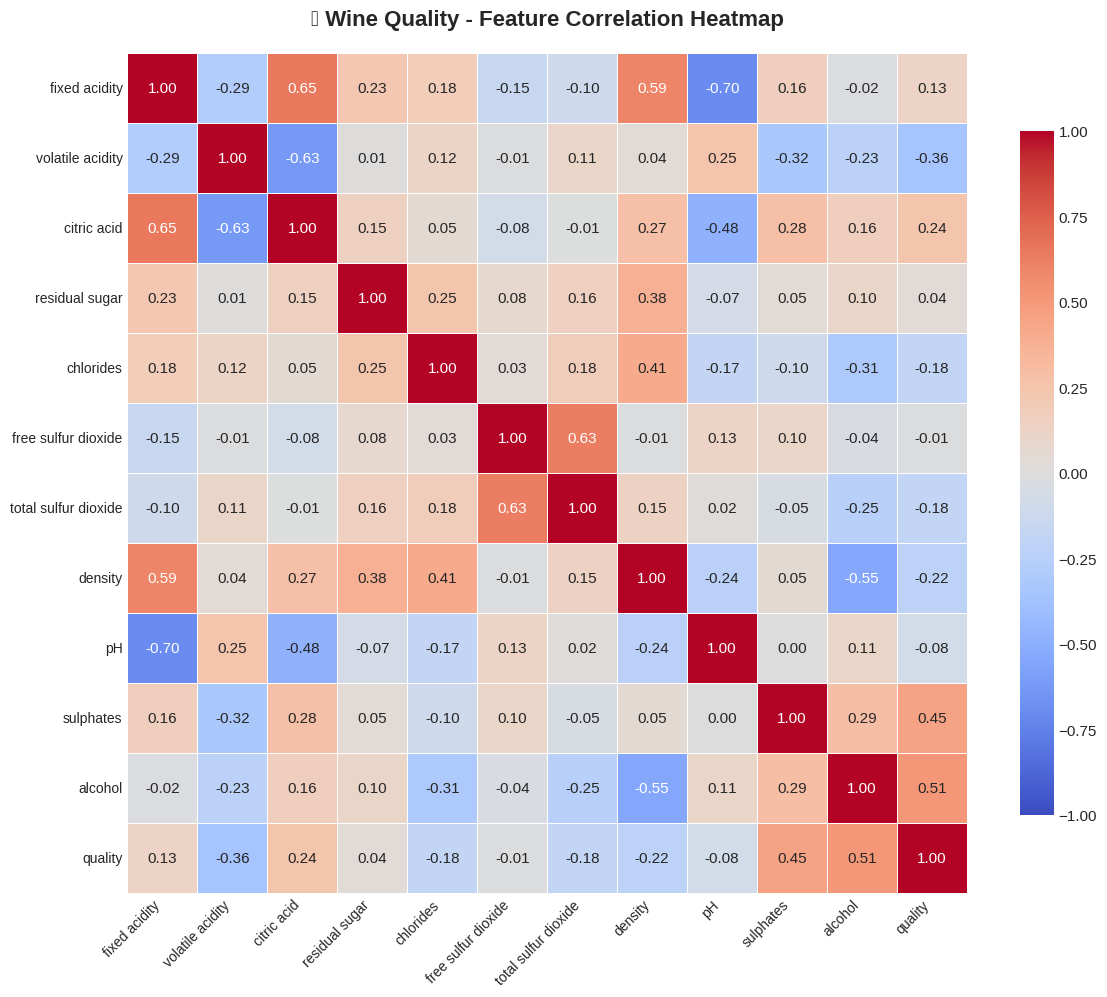


📊 Top Feature Correlations with Quality:
----------------------------------------
   🟢 alcohol                        +0.510
   🟢 sulphates                      +0.448
   🔴 volatile acidity               -0.357
   🟢 citric acid                    +0.243
   🔴 density                        -0.221
   🔴 chlorides                      -0.185
   🔴 total sulfur dioxide           -0.180
   🟢 fixed acidity                  +0.130
   🔴 pH                             -0.079
   🟢 residual sugar                 +0.035
   🔴 free sulfur dioxide            -0.012


In [7]:
# Correlation Heatmap
print("🔥 Feature Correlation Heatmap")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title('🍷 Wine Quality - Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Top correlations with quality
print("\n📊 Top Feature Correlations with Quality:")
print("-" * 40)
quality_corr = corr_matrix['quality'].drop('quality').sort_values(key=abs, ascending=False)
for feat, val in quality_corr.items():
    direction = "🔴" if val < 0 else "🟢"
    print(f"   {direction} {feat:<30} {val:+.3f}")

In [8]:
# Create binary classification target (Good vs Not Good)
# Quality >= 7 is considered "Good" wine
y_binary = (y >= 7).astype(int)

print("🎯 Binary Classification Target:")
print(f"   0 (Not Good, Quality < 7): {(y_binary == 0).sum()}")
print(f"   1 (Good, Quality >= 7): {(y_binary == 1).sum()}")
print(f"   Class Ratio: {(y_binary == 0).sum() / (y_binary == 1).sum():.2f}:1")

🎯 Binary Classification Target:
   0 (Not Good, Quality < 7): 860
   1 (Good, Quality >= 7): 125
   Class Ratio: 6.88:1


In [9]:
# Create multi-class classification target (Low, Medium, High)
def categorize_quality(q):
    if q <= 4:
        return 0  # Low
    elif q <= 6:
        return 1  # Medium
    else:
        return 2  # High

y_multi = y.apply(categorize_quality)

print("🎯 Multi-Class Classification Target:")
print(f"   0 (Low, Quality 3-4): {(y_multi == 0).sum()}")
print(f"   1 (Medium, Quality 5-6): {(y_multi == 1).sum()}")
print(f"   2 (High, Quality 7-8): {(y_multi == 2).sum()}")

🎯 Multi-Class Classification Target:
   0 (Low, Quality 3-4): 34
   1 (Medium, Quality 5-6): 826
   2 (High, Quality 7-8): 125


In [10]:
# Train-Test Split for all target types
# Regression target (original quality scores)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Binary classification target
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary
)

# Multi-class classification target
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.2, random_state=RANDOM_STATE, stratify=y_multi
)

print("✅ Train-Test Split Complete!")
print(f"\n📊 Training set size: {X_train.shape[0]}")
print(f"📊 Test set size: {X_test.shape[0]}")

✅ Train-Test Split Complete!

📊 Training set size: 788
📊 Test set size: 197


In [11]:
# Feature Scaling
scaler = StandardScaler()

# Scale for regression
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale for binary classification
scaler_bin = StandardScaler()
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_bin.transform(X_test_bin)

# Scale for multi-class classification
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)
X_test_multi_scaled = scaler_multi.transform(X_test_multi)

print("✅ Feature scaling complete!")
print(f"\n📊 Scaled features - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.4f}")

✅ Feature scaling complete!

📊 Scaled features - Mean: -0.000000, Std: 1.0000


---
## 3. Feature Engineering

In [12]:
# Create additional features based on domain knowledge
df_fe = df.copy()

# Ratio features
df_fe['total_acidity'] = df_fe['fixed acidity'] + df_fe['volatile acidity']
df_fe['acidity_ratio'] = df_fe['fixed acidity'] / (df_fe['volatile acidity'] + 0.001)
df_fe['free_sulfur_ratio'] = df_fe['free sulfur dioxide'] / (df_fe['total sulfur dioxide'] + 0.001)
df_fe['alcohol_density_ratio'] = df_fe['alcohol'] / df_fe['density']
df_fe['sugar_alcohol_ratio'] = df_fe['residual sugar'] / (df_fe['alcohol'] + 0.001)

# Interaction features
df_fe['alcohol_sulphates'] = df_fe['alcohol'] * df_fe['sulphates']
df_fe['acidity_pH'] = df_fe['total_acidity'] * df_fe['pH']

print("✅ Feature Engineering Complete!")
print(f"\n📊 Original features: {X.shape[1]}")
print(f"📊 New features: {df_fe.shape[1] - df.shape[1]}")
print(f"📊 Total features: {df_fe.shape[1] - 1}")

print("\n📋 New Features Created:")
new_features = ['total_acidity', 'acidity_ratio', 'free_sulfur_ratio',
                'alcohol_density_ratio', 'sugar_alcohol_ratio', 'alcohol_sulphates', 'acidity_pH']
for feat in new_features:
    print(f"   • {feat}")

✅ Feature Engineering Complete!

📊 Original features: 11
📊 New features: 7
📊 Total features: 18

📋 New Features Created:
   • total_acidity
   • acidity_ratio
   • free_sulfur_ratio
   • alcohol_density_ratio
   • sugar_alcohol_ratio
   • alcohol_sulphates
   • acidity_pH


In [13]:
# Prepare feature engineered data
X_fe = df_fe.drop('quality', axis=1)
y_fe = df_fe['quality']

# Split and scale
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE
)

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

print(f"✅ Feature engineered dataset ready!")
print(f"📊 Shape: {X_fe.shape}")

✅ Feature engineered dataset ready!
📊 Shape: (985, 18)


📊 Correlation of New Features with Quality:
alcohol_sulphates        0.5735
alcohol_density_ratio    0.5084
acidity_ratio            0.3251
free_sulfur_ratio        0.2296
total_acidity            0.0910
acidity_pH               0.0818
sugar_alcohol_ratio     -0.1825
Name: quality, dtype: float64


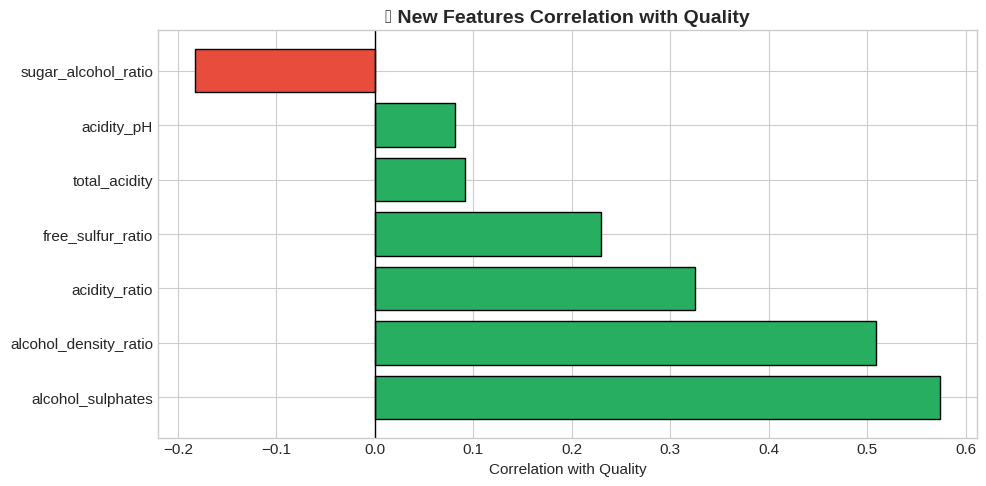

In [14]:
# Correlation of new features with quality
print("📊 Correlation of New Features with Quality:")
print("=" * 50)

new_feat_corr = df_fe[new_features + ['quality']].corr()['quality'].drop('quality').sort_values(ascending=False)
print(new_feat_corr.round(4))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in new_feat_corr.values]
ax.barh(new_feat_corr.index, new_feat_corr.values, color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Correlation with Quality')
ax.set_title('📊 New Features Correlation with Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Model Building - Classification

In [15]:
# Define classification models
classification_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, verbose=-1),
    'SVM': SVC(random_state=RANDOM_STATE, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Extra Trees': ExtraTreesClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE, n_estimators=100)
}

print(f"✅ {len(classification_models)} Classification Models Defined!")
for name in classification_models.keys():
    print(f"   • {name}")

✅ 11 Classification Models Defined!
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • Gradient Boosting
   • XGBoost
   • LightGBM
   • SVM
   • KNN
   • Naive Bayes
   • Extra Trees
   • AdaBoost


In [16]:
# Function to evaluate classification models
def evaluate_classification_models(models, X_train, X_test, y_train, y_test, model_type='Binary'):
    results = []

    print(f"\n{'='*80}")
    print(f"🎯 {model_type} CLASSIFICATION MODEL EVALUATION")
    print(f"{'='*80}\n")

    for name, model in models.items():
        print(f"Training {name}...", end=' ')

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'CV Mean': cv_scores.mean(),
            'CV Std': cv_scores.std()
        })

        print(f"✓ (Accuracy: {accuracy:.4f}, F1: {f1:.4f})")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

    return results_df

In [17]:
# Evaluate Binary Classification Models
binary_results = evaluate_classification_models(
    classification_models.copy(),
    X_train_bin_scaled, X_test_bin_scaled,
    y_train_bin, y_test_bin,
    model_type='Binary'
)

print("\n📊 Binary Classification Results (Sorted by F1-Score):")
print("=" * 80)
binary_results.round(4)


🎯 Binary CLASSIFICATION MODEL EVALUATION

Training Logistic Regression... ✓ (Accuracy: 0.8934, F1: 0.8800)
Training Decision Tree... ✓ (Accuracy: 0.8173, F1: 0.8298)
Training Random Forest... ✓ (Accuracy: 0.8934, F1: 0.8800)
Training Gradient Boosting... ✓ (Accuracy: 0.8934, F1: 0.8905)
Training XGBoost... ✓ (Accuracy: 0.9036, F1: 0.8989)
Training LightGBM... ✓ (Accuracy: 0.8832, F1: 0.8749)
Training SVM... ✓ (Accuracy: 0.8832, F1: 0.8505)
Training KNN... ✓ (Accuracy: 0.8477, F1: 0.8420)
Training Naive Bayes... ✓ (Accuracy: 0.8223, F1: 0.8416)
Training Extra Trees... ✓ (Accuracy: 0.8934, F1: 0.8831)
Training AdaBoost... ✓ (Accuracy: 0.8985, F1: 0.8900)

📊 Binary Classification Results (Sorted by F1-Score):


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,XGBoost,0.9036,0.8964,0.9036,0.8989,0.8705,0.0237
1,Gradient Boosting,0.8934,0.8882,0.8934,0.8905,0.8807,0.0224
2,AdaBoost,0.8985,0.8873,0.8985,0.8900,0.8795,0.0261
3,Extra Trees,0.8934,0.8801,0.8934,0.8831,0.8908,0.0065
4,Logistic Regression,0.8934,0.8783,0.8934,0.8800,0.8883,0.0089
5,Random Forest,0.8934,0.8783,0.8934,0.8800,0.8871,0.0060
6,LightGBM,0.8832,0.8704,0.8832,0.8749,0.8782,0.0199
7,SVM,0.8832,0.8617,0.8832,0.8505,0.8947,0.0087
8,KNN,0.8477,0.8371,0.8477,0.8420,0.8782,0.0116
9,Naive Bayes,0.8223,0.8765,0.8223,0.8416,0.8566,0.0241


In [18]:
# Evaluate Multi-Class Classification Models
multi_results = evaluate_classification_models(
    classification_models.copy(),
    X_train_multi_scaled, X_test_multi_scaled,
    y_train_multi, y_test_multi,
    model_type='Multi-Class'
)

print("\n📊 Multi-Class Classification Results (Sorted by F1-Score):")
print("=" * 80)
multi_results.round(4)


🎯 Multi-Class CLASSIFICATION MODEL EVALUATION

Training Logistic Regression... ✓ (Accuracy: 0.8782, F1: 0.8581)
Training Decision Tree... ✓ (Accuracy: 0.8223, F1: 0.8296)
Training Random Forest... ✓ (Accuracy: 0.8629, F1: 0.8295)
Training Gradient Boosting... ✓ (Accuracy: 0.8528, F1: 0.8365)
Training XGBoost... ✓ (Accuracy: 0.8731, F1: 0.8444)
Training LightGBM... ✓ (Accuracy: 0.8731, F1: 0.8470)
Training SVM... ✓ (Accuracy: 0.8629, F1: 0.8258)
Training KNN... ✓ (Accuracy: 0.8426, F1: 0.8172)
Training Naive Bayes... ✓ (Accuracy: 0.7919, F1: 0.8016)
Training Extra Trees... ✓ (Accuracy: 0.8731, F1: 0.8341)
Training AdaBoost... ✓ (Accuracy: 0.8223, F1: 0.8110)

📊 Multi-Class Classification Results (Sorted by F1-Score):


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Logistic Regression,0.8782,0.8736,0.8782,0.8581,0.8502,0.0187
1,LightGBM,0.8731,0.8340,0.8731,0.8470,0.8426,0.0127
2,XGBoost,0.8731,0.8350,0.8731,0.8444,0.8426,0.0139
3,Gradient Boosting,0.8528,0.8318,0.8528,0.8365,0.8426,0.0161
4,Extra Trees,0.8731,0.8543,0.8731,0.8341,0.8591,0.0181
5,Decision Tree,0.8223,0.8397,0.8223,0.8296,0.7931,0.0234
6,Random Forest,0.8629,0.8218,0.8629,0.8295,0.8629,0.0150
7,SVM,0.8629,0.8249,0.8629,0.8258,0.8515,0.0135
8,KNN,0.8426,0.8261,0.8426,0.8172,0.8388,0.0203
9,AdaBoost,0.8223,0.7999,0.8223,0.8110,0.8058,0.0192


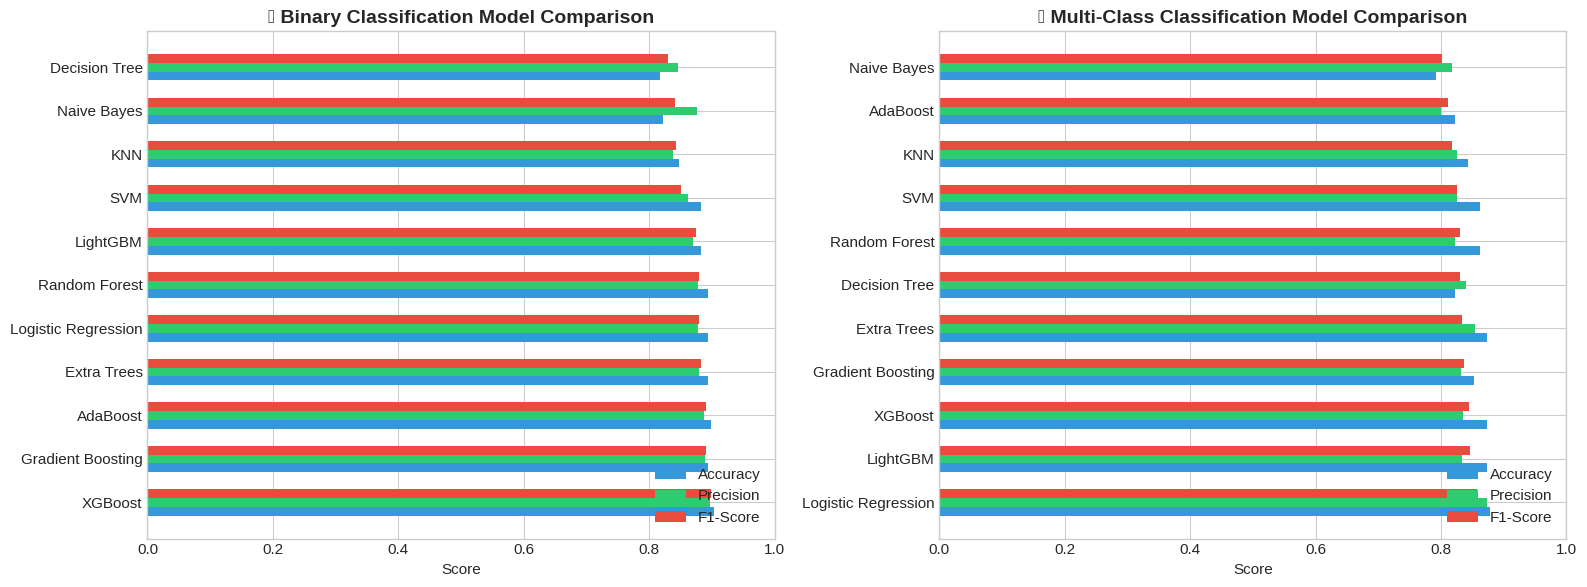

In [19]:
# Visualize Classification Results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binary Classification
ax1 = axes[0]
x_pos = np.arange(len(binary_results))
width = 0.2

ax1.barh(x_pos - width, binary_results['Accuracy'], width, label='Accuracy', color='#3498db')
ax1.barh(x_pos, binary_results['Precision'], width, label='Precision', color='#2ecc71')
ax1.barh(x_pos + width, binary_results['F1-Score'], width, label='F1-Score', color='#e74c3c')

ax1.set_yticks(x_pos)
ax1.set_yticklabels(binary_results['Model'])
ax1.set_xlabel('Score')
ax1.set_title('🎯 Binary Classification Model Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.set_xlim(0, 1)

# Multi-Class Classification
ax2 = axes[1]
x_pos = np.arange(len(multi_results))

ax2.barh(x_pos - width, multi_results['Accuracy'], width, label='Accuracy', color='#3498db')
ax2.barh(x_pos, multi_results['Precision'], width, label='Precision', color='#2ecc71')
ax2.barh(x_pos + width, multi_results['F1-Score'], width, label='F1-Score', color='#e74c3c')

ax2.set_yticks(x_pos)
ax2.set_yticklabels(multi_results['Model'])
ax2.set_xlabel('Score')
ax2.set_title('🎯 Multi-Class Classification Model Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

🏆 Best Binary Classification Model: XGBoost


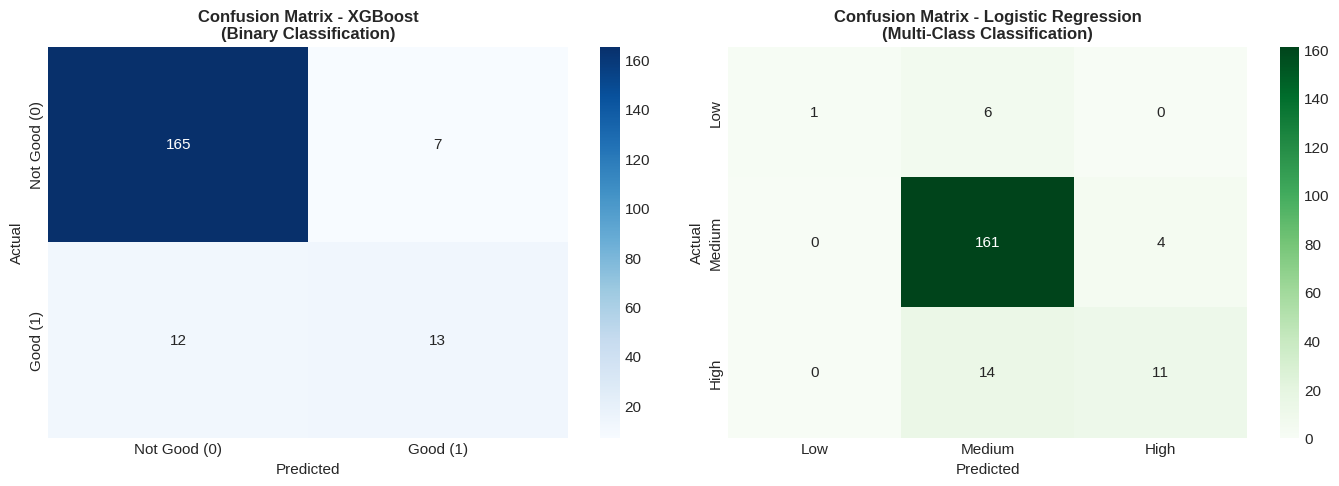


📋 Classification Report - XGBoost (Binary):
              precision    recall  f1-score   support

    Not Good       0.93      0.96      0.95       172
        Good       0.65      0.52      0.58        25

    accuracy                           0.90       197
   macro avg       0.79      0.74      0.76       197
weighted avg       0.90      0.90      0.90       197


📋 Classification Report - Logistic Regression (Multi-Class):
              precision    recall  f1-score   support

         Low       1.00      0.14      0.25         7
      Medium       0.89      0.98      0.93       165
        High       0.73      0.44      0.55        25

    accuracy                           0.88       197
   macro avg       0.87      0.52      0.58       197
weighted avg       0.87      0.88      0.86       197



In [20]:
# Confusion Matrix for Best Binary Classification Model
best_binary_model_name = binary_results.iloc[0]['Model']
print(f"🏆 Best Binary Classification Model: {best_binary_model_name}")

# Retrain best model
# Instead of retrieving the original instance, create a new one with explicit binary objective
if best_binary_model_name == 'XGBoost':
    best_binary_model = XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='logloss', # eval_metric is appropriate for binary classification
        objective='binary:logistic' # Explicitly set objective for binary
    )
else:
    # For other models, retrieve the instance from the dictionary (which are already configured)
    best_binary_model = classification_models[best_binary_model_name]

best_binary_model.fit(X_train_bin_scaled, y_train_bin)
y_pred_binary = best_binary_model.predict(X_test_bin_scaled)

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary CM
cm_binary = confusion_matrix(y_test_bin, y_pred_binary)
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Good (0)', 'Good (1)'],
            yticklabels=['Not Good (0)', 'Good (1)'])
axes[0].set_title(f'Confusion Matrix - {best_binary_model_name}\n(Binary Classification)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Multi-class CM
best_multi_model_name = multi_results.iloc[0]['Model']
best_multi_model = classification_models[best_multi_model_name]

# If the best multi-class model is XGBoost or LightGBM, re-initialize it with appropriate multi-class objective/metric
if best_multi_model_name == 'XGBoost':
    best_multi_model = XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='mlogloss', # eval_metric for multi-class
        objective='multi:softprob' # Explicitly set objective for multi-class
    )
elif best_multi_model_name == 'LightGBM':
    best_multi_model = LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, verbose=-1, objective='multiclass')
else:
    best_multi_model = classification_models[best_multi_model_name]

best_multi_model.fit(X_train_multi_scaled, y_train_multi)
y_pred_multi = best_multi_model.predict(X_test_multi_scaled)

cm_multi = confusion_matrix(y_test_multi, y_pred_multi)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f'Confusion Matrix - {best_multi_model_name}\n(Multi-Class Classification)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Classification Reports
print(f"\n📋 Classification Report - {best_binary_model_name} (Binary):")
print("=" * 60)
print(classification_report(y_test_bin, y_pred_binary, target_names=['Not Good', 'Good']))

print(f"\n📋 Classification Report - {best_multi_model_name} (Multi-Class):")
print("=" * 60)
print(classification_report(y_test_multi, y_pred_multi, target_names=['Low', 'Medium', 'High']))

---
## 5. Model Building - Regression

In [21]:
# Define regression models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'LightGBM': LGBMRegressor(random_state=RANDOM_STATE, n_estimators=100, verbose=-1),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Extra Trees': ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'AdaBoost': AdaBoostRegressor(random_state=RANDOM_STATE, n_estimators=100)
}

print(f"✅ {len(regression_models)} Regression Models Defined!")
for name in regression_models.keys():
    print(f"   • {name}")

✅ 13 Regression Models Defined!
   • Linear Regression
   • Ridge Regression
   • Lasso Regression
   • ElasticNet
   • Decision Tree
   • Random Forest
   • Gradient Boosting
   • XGBoost
   • LightGBM
   • SVR
   • KNN
   • Extra Trees
   • AdaBoost


In [22]:
# Function to evaluate regression models
def evaluate_regression_models(models, X_train, X_test, y_train, y_test):
    results = []

    print(f"\n{'='*80}")
    print(f"📈 REGRESSION MODEL EVALUATION")
    print(f"{'='*80}\n")

    for name, model in models.items():
        print(f"Training {name}...", end=' ')

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

        # Metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Model': name,
            'R2 Score': r2,
            'RMSE': rmse,
            'MAE': mae,
            'MSE': mse,
            'CV Mean R2': cv_scores.mean(),
            'CV Std': cv_scores.std()
        })

        print(f"✓ (R2: {r2:.4f}, RMSE: {rmse:.4f})")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('R2 Score', ascending=False).reset_index(drop=True)

    return results_df

In [23]:
# Evaluate Regression Models (Original Features)
regression_results = evaluate_regression_models(
    regression_models.copy(),
    X_train_scaled, X_test_scaled,
    y_train_reg, y_test_reg
)

print("\n📊 Regression Results - Original Features (Sorted by R2 Score):")
print("=" * 80)
regression_results.round(4)


📈 REGRESSION MODEL EVALUATION

Training Linear Regression... ✓ (R2: 0.4490, RMSE: 0.6394)
Training Ridge Regression... ✓ (R2: 0.4489, RMSE: 0.6395)
Training Lasso Regression... ✓ (R2: -0.0008, RMSE: 0.8618)
Training ElasticNet... ✓ (R2: -0.0008, RMSE: 0.8618)
Training Decision Tree... ✓ (R2: -0.0191, RMSE: 0.8697)
Training Random Forest... ✓ (R2: 0.4383, RMSE: 0.6457)
Training Gradient Boosting... ✓ (R2: 0.4306, RMSE: 0.6501)
Training XGBoost... ✓ (R2: 0.3815, RMSE: 0.6775)
Training LightGBM... ✓ (R2: 0.4078, RMSE: 0.6629)
Training SVR... ✓ (R2: 0.4396, RMSE: 0.6449)
Training KNN... ✓ (R2: 0.2753, RMSE: 0.7334)
Training Extra Trees... ✓ (R2: 0.4561, RMSE: 0.6353)
Training AdaBoost... ✓ (R2: 0.3485, RMSE: 0.6953)

📊 Regression Results - Original Features (Sorted by R2 Score):


,Model,R2 Score,RMSE,MAE,MSE,CV Mean R2,CV Std
0,Extra Trees,0.4561,0.6353,0.5147,0.4036,0.3224,0.0734
1,Linear Regression,0.4490,0.6394,0.5163,0.4089,0.3415,0.0346
2,Ridge Regression,0.4489,0.6395,0.5164,0.4090,0.3418,0.0347
3,SVR,0.4396,0.6449,0.5056,0.4159,0.2834,0.0699
4,Random Forest,0.4383,0.6457,0.5216,0.4169,0.3346,0.0688
5,Gradient Boosting,0.4306,0.6501,0.5294,0.4226,0.3008,0.0650
6,LightGBM,0.4078,0.6629,0.5318,0.4395,0.2475,0.0815
7,XGBoost,0.3815,0.6775,0.5367,0.4590,0.2249,0.0871
8,AdaBoost,0.3485,0.6953,0.5599,0.4835,0.2314,0.0835
9,KNN,0.2753,0.7334,0.5838,0.5379,0.2191,0.1081


In [24]:
# Evaluate Regression Models (Feature Engineered)
regression_results_fe = evaluate_regression_models(
    {k: v.__class__(**v.get_params()) for k, v in regression_models.items()},
    X_train_fe_scaled, X_test_fe_scaled,
    y_train_fe, y_test_fe
)

print("\n📊 Regression Results - Feature Engineered (Sorted by R2 Score):")
print("=" * 80)
regression_results_fe.round(4)


📈 REGRESSION MODEL EVALUATION

Training Linear Regression... ✓ (R2: 0.4625, RMSE: 0.6316)
Training Ridge Regression... ✓ (R2: 0.4635, RMSE: 0.6310)
Training Lasso Regression... ✓ (R2: -0.0008, RMSE: 0.8618)
Training ElasticNet... ✓ (R2: -0.0008, RMSE: 0.8618)
Training Decision Tree... ✓ (R2: 0.0971, RMSE: 0.8186)
Training Random Forest... ✓ (R2: 0.4594, RMSE: 0.6334)
Training Gradient Boosting... ✓ (R2: 0.4455, RMSE: 0.6415)
Training XGBoost... ✓ (R2: 0.3519, RMSE: 0.6935)
Training LightGBM... ✓ (R2: 0.4089, RMSE: 0.6623)
Training SVR... ✓ (R2: 0.4644, RMSE: 0.6305)
Training KNN... ✓ (R2: 0.3095, RMSE: 0.7159)
Training Extra Trees... ✓ (R2: 0.4403, RMSE: 0.6445)
Training AdaBoost... ✓ (R2: 0.3310, RMSE: 0.7046)

📊 Regression Results - Feature Engineered (Sorted by R2 Score):


,Model,R2 Score,RMSE,MAE,MSE,CV Mean R2,CV Std
0,SVR,0.4644,0.6305,0.4939,0.3975,0.2731,0.0845
1,Ridge Regression,0.4635,0.6310,0.5086,0.3982,0.3446,0.0462
2,Linear Regression,0.4625,0.6316,0.5098,0.3989,0.3435,0.0465
3,Random Forest,0.4594,0.6334,0.5061,0.4012,0.3281,0.0718
4,Gradient Boosting,0.4455,0.6415,0.5207,0.4115,0.3091,0.0725
5,Extra Trees,0.4403,0.6445,0.5134,0.4154,0.3141,0.0807
6,LightGBM,0.4089,0.6623,0.5336,0.4387,0.2583,0.1050
7,XGBoost,0.3519,0.6935,0.5535,0.4810,0.2363,0.0980
8,AdaBoost,0.3310,0.7046,0.5762,0.4965,0.2328,0.0848
9,KNN,0.3095,0.7159,0.5624,0.5125,0.2228,0.0861


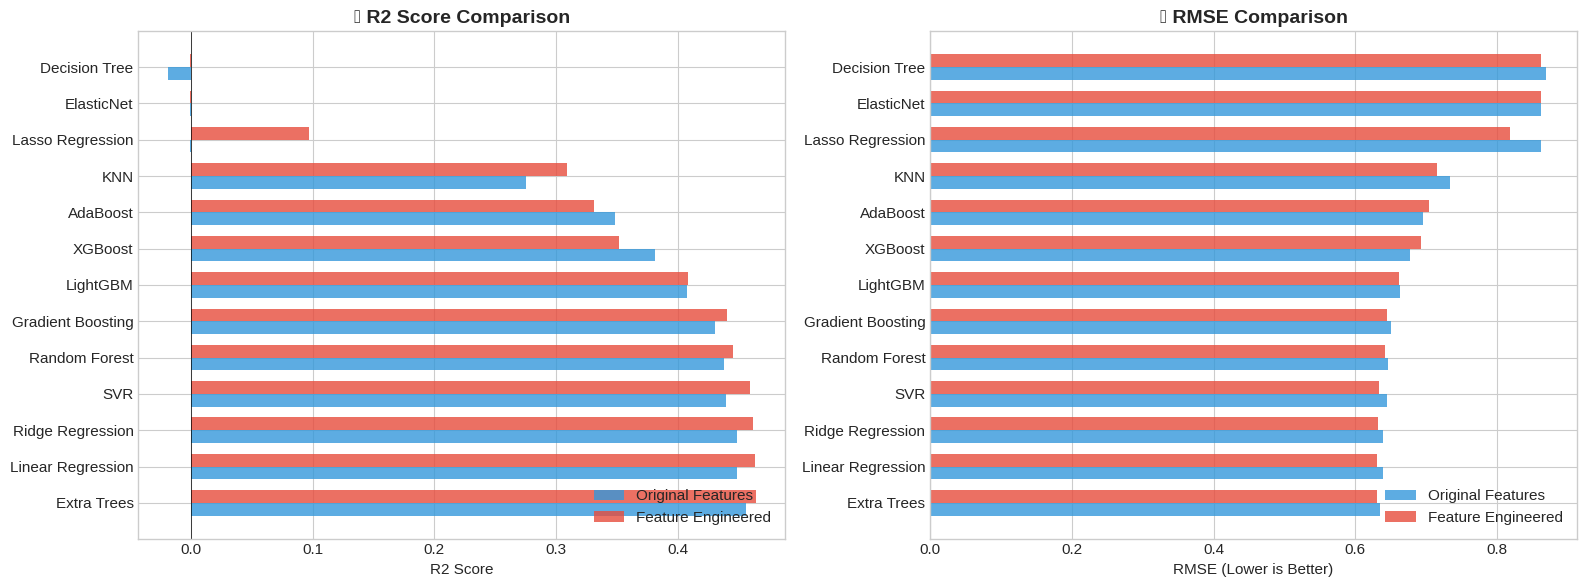

In [25]:
# Visualize Regression Results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Score Comparison
ax1 = axes[0]
x_pos = np.arange(len(regression_results))
width = 0.35

bars1 = ax1.barh(x_pos - width/2, regression_results['R2 Score'], width,
                  label='Original Features', color='#3498db', alpha=0.8)
bars2 = ax1.barh(x_pos + width/2, regression_results_fe['R2 Score'], width,
                  label='Feature Engineered', color='#e74c3c', alpha=0.8)

ax1.set_yticks(x_pos)
ax1.set_yticklabels(regression_results['Model'])
ax1.set_xlabel('R2 Score')
ax1.set_title('📈 R2 Score Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# RMSE Comparison
ax2 = axes[1]
bars1 = ax2.barh(x_pos - width/2, regression_results['RMSE'], width,
                  label='Original Features', color='#3498db', alpha=0.8)
bars2 = ax2.barh(x_pos + width/2, regression_results_fe['RMSE'], width,
                  label='Feature Engineered', color='#e74c3c', alpha=0.8)

ax2.set_yticks(x_pos)
ax2.set_yticklabels(regression_results['Model'])
ax2.set_xlabel('RMSE (Lower is Better)')
ax2.set_title('📈 RMSE Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

🏆 Best Regression Model: Extra Trees


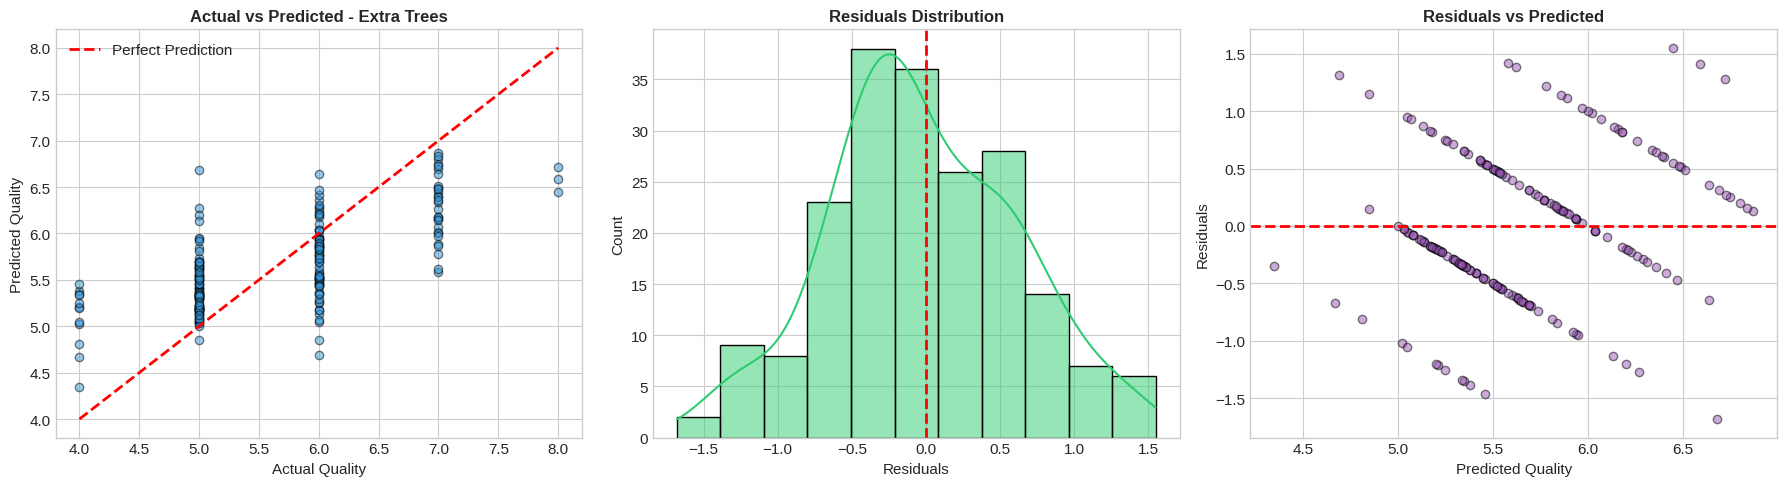


📊 Regression Metrics for Extra Trees:
   R2 Score: 0.4561
   RMSE: 0.6353
   MAE: 0.5147


In [26]:
# Actual vs Predicted for Best Regression Model
best_reg_model_name = regression_results.iloc[0]['Model']
print(f"🏆 Best Regression Model: {best_reg_model_name}")

# Retrain best model
best_reg_model = regression_models[best_reg_model_name]
best_reg_model.fit(X_train_scaled, y_train_reg)
y_pred_reg = best_reg_model.predict(X_test_scaled)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='#3498db', edgecolor='black')
ax1.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Quality')
ax1.set_ylabel('Predicted Quality')
ax1.set_title(f'Actual vs Predicted - {best_reg_model_name}', fontsize=12, fontweight='bold')
ax1.legend()

# Residuals Distribution
ax2 = axes[1]
residuals = y_test_reg - y_pred_reg
sns.histplot(residuals, kde=True, ax=ax2, color='#2ecc71')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residuals')
ax2.set_title('Residuals Distribution', fontsize=12, fontweight='bold')

# Residuals vs Predicted
ax3 = axes[2]
ax3.scatter(y_pred_reg, residuals, alpha=0.5, color='#9b59b6', edgecolor='black')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Quality')
ax3.set_ylabel('Residuals')
ax3.set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Regression Metrics for {best_reg_model_name}:")
print(f"   R2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")
print(f"   MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")

---
## 6. Hyperparameter Tuning

In [27]:
# Hyperparameter tuning for top models
print("🔧 Hyperparameter Tuning for Top Models")
print("=" * 60)

# Random Forest Tuning
rf_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print("\n🌲 Tuning Random Forest Classifier...")
rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_grid.fit(X_train_multi_scaled, y_train_multi)

print(f"   Best Parameters: {rf_grid.best_params_}")
print(f"   Best CV Score: {rf_grid.best_score_:.4f}")

🔧 Hyperparameter Tuning for Top Models

🌲 Tuning Random Forest Classifier...
   Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5}
   Best CV Score: 0.8338


In [28]:
# XGBoost Tuning
xgb_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

print("\n🚀 Tuning XGBoost Classifier...")
xgb_grid = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='mlogloss'),
    xgb_params,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_grid.fit(X_train_multi_scaled, y_train_multi)

print(f"   Best Parameters: {xgb_grid.best_params_}")
print(f"   Best CV Score: {xgb_grid.best_score_:.4f}")


🚀 Tuning XGBoost Classifier...
   Best Parameters: {'subsample': 0.6, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
   Best CV Score: 0.8345


In [29]:
# LightGBM Tuning
lgbm_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 70],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

print("\n💡 Tuning LightGBM Classifier...")
lgbm_grid = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    lgbm_params,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lgbm_grid.fit(X_train_multi_scaled, y_train_multi)

print(f"   Best Parameters: {lgbm_grid.best_params_}")
print(f"   Best CV Score: {lgbm_grid.best_score_:.4f}")


💡 Tuning LightGBM Classifier...
   Best Parameters: {'subsample': 1.0, 'num_leaves': 70, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
   Best CV Score: 0.8319


In [30]:
# Compare Tuned Models
print("\n📊 Tuned Models Comparison:")
print("=" * 60)

tuned_models = {
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'XGBoost (Tuned)': xgb_grid.best_estimator_,
    'LightGBM (Tuned)': lgbm_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_multi_scaled)

    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_multi, y_pred),
        'Precision': precision_score(y_test_multi, y_pred, average='weighted'),
        'Recall': recall_score(y_test_multi, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test_multi, y_pred, average='weighted')
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values('F1-Score', ascending=False)
tuned_results_df.round(4)


📊 Tuned Models Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
2,LightGBM (Tuned),0.8883,0.8528,0.8883,0.8648
1,XGBoost (Tuned),0.8832,0.8523,0.8832,0.8622
0,Random Forest (Tuned),0.8782,0.8488,0.8782,0.8457


---
## 7. Model Comparison & Evaluation

In [31]:
# Comprehensive Model Comparison
print("📊 Comprehensive Model Comparison")
print("=" * 80)

# Combine all results
all_results = pd.concat([
    binary_results.assign(Task='Binary Classification'),
    multi_results.assign(Task='Multi-Class Classification')
], ignore_index=True)

# Summary table
print("\n🏆 Top 5 Models by F1-Score (Classification):")
print("-" * 60)
top_models = all_results.nlargest(5, 'F1-Score')[['Model', 'Task', 'Accuracy', 'F1-Score', 'CV Mean']]
print(top_models.to_string(index=False))

print("\n🏆 Top 5 Models by R2 Score (Regression):")
print("-" * 60)
top_reg = regression_results.nlargest(5, 'R2 Score')[['Model', 'R2 Score', 'RMSE', 'MAE', 'CV Mean R2']]
print(top_reg.to_string(index=False))

📊 Comprehensive Model Comparison

🏆 Top 5 Models by F1-Score (Classification):
------------------------------------------------------------
              Model                  Task  Accuracy  F1-Score  CV Mean
            XGBoost Binary Classification    0.9036    0.8989   0.8705
  Gradient Boosting Binary Classification    0.8934    0.8905   0.8807
           AdaBoost Binary Classification    0.8985    0.8900   0.8795
        Extra Trees Binary Classification    0.8934    0.8831   0.8908
Logistic Regression Binary Classification    0.8934    0.8800   0.8883

🏆 Top 5 Models by R2 Score (Regression):
------------------------------------------------------------
            Model  R2 Score   RMSE    MAE  CV Mean R2
      Extra Trees    0.4561 0.6353 0.5147      0.3224
Linear Regression    0.4490 0.6394 0.5163      0.3415
 Ridge Regression    0.4489 0.6395 0.5164      0.3418
              SVR    0.4396 0.6449 0.5056      0.2834
    Random Forest    0.4383 0.6457 0.5216      0.3346


📊 Cross-Validation Analysis


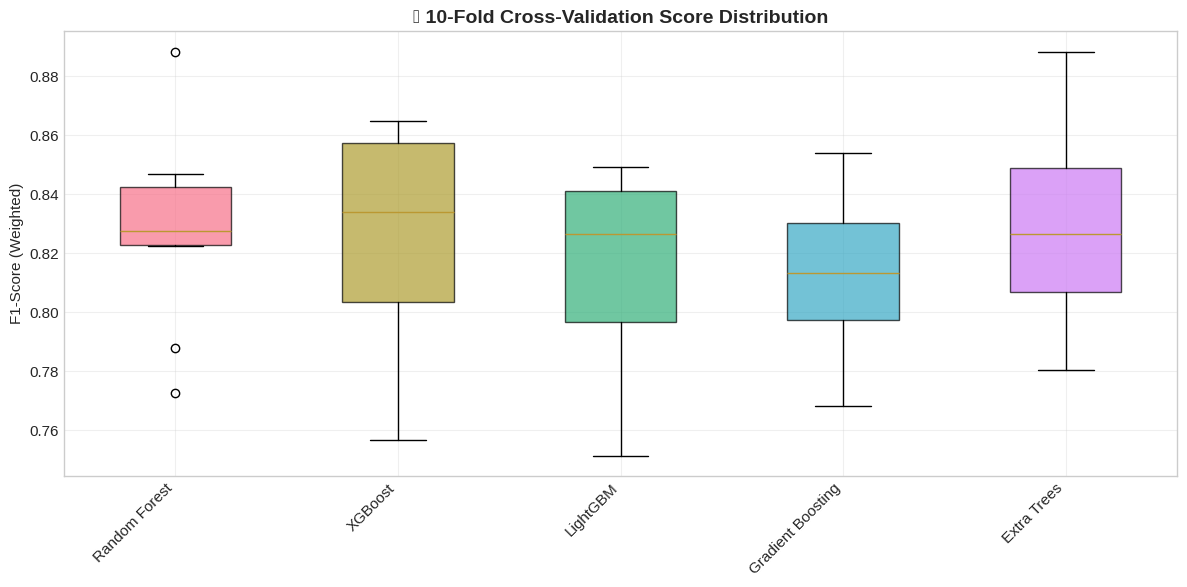


CV Statistics (10-Fold):
   Random Forest: Mean=0.8281, Std=0.0302
   XGBoost: Mean=0.8268, Std=0.0347
   LightGBM: Mean=0.8171, Std=0.0307
   Gradient Boosting: Mean=0.8131, Std=0.0282
   Extra Trees: Mean=0.8281, Std=0.0313


In [32]:
# Cross-Validation Score Distribution
print("📊 Cross-Validation Analysis")
print("=" * 60)

# Get CV scores for top models
cv_models = {
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, verbose=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'Extra Trees': ExtraTreesClassifier(random_state=RANDOM_STATE, n_estimators=100)
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_multi_scaled, y_train_multi, cv=10, scoring='f1_weighted')
    cv_results[name] = scores

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot([cv_results[m] for m in cv_models.keys()], patch_artist=True)

colors = sns.color_palette('husl', n_colors=len(cv_models))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(cv_models.keys(), rotation=45, ha='right')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_title('📊 10-Fold Cross-Validation Score Distribution', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print stats
print("\nCV Statistics (10-Fold):")
for name, scores in cv_results.items():
    print(f"   {name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

📈 ROC Curves for Binary Classification


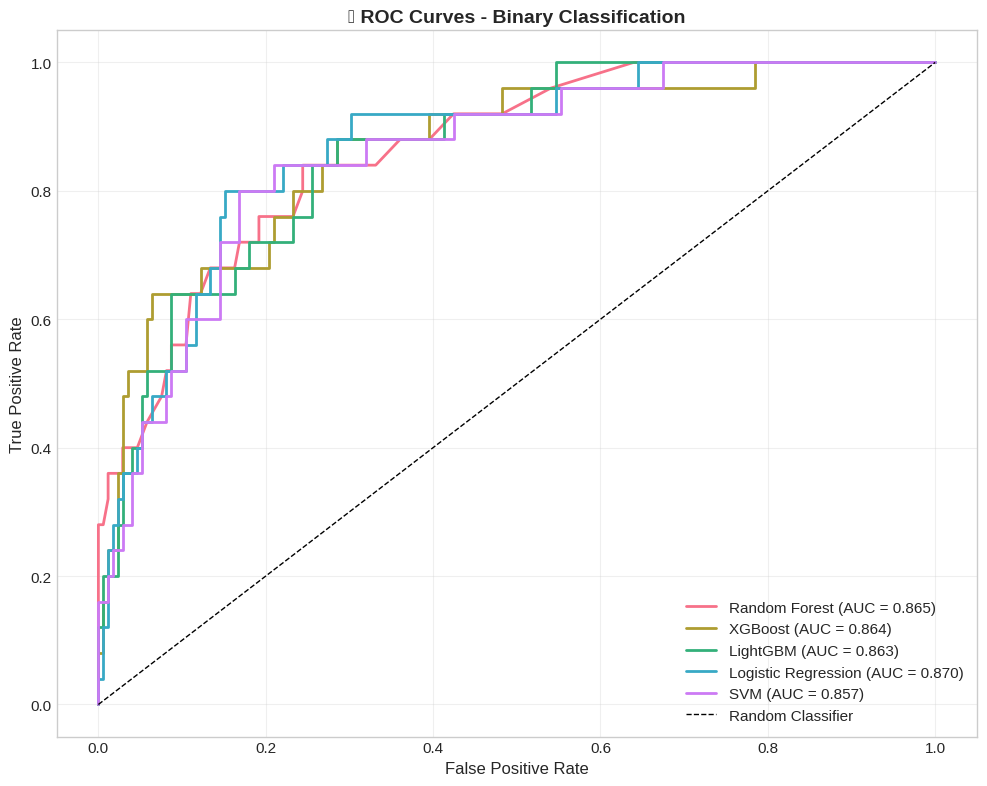

In [33]:
# ROC Curves for Binary Classification
print("📈 ROC Curves for Binary Classification")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 8))

roc_models = {
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, verbose=-1),
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'SVM': SVC(random_state=RANDOM_STATE, probability=True)
}

colors = sns.color_palette('husl', n_colors=len(roc_models))

for (name, model), color in zip(roc_models.items(), colors):
    model.fit(X_train_bin_scaled, y_train_bin)
    y_proba = model.predict_proba(X_test_bin_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
    auc = roc_auc_score(y_test_bin, y_proba)

    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('📈 ROC Curves - Binary Classification', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Feature Importance Analysis

In [34]:
# Feature Importance from Multiple Models
print("📊 Feature Importance Analysis")
print("=" * 60)

# Train models for feature importance
rf_model = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
rf_model.fit(X_train_multi_scaled, y_train_multi)

xgb_model = XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_multi_scaled, y_train_multi)

lgbm_model = LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, verbose=-1)
lgbm_model.fit(X_train_multi_scaled, y_train_multi)

# Get feature importances
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Random Forest': rf_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_,
    'LightGBM': lgbm_model.feature_importances_
})

importance_df['Average'] = importance_df[['Random Forest', 'XGBoost', 'LightGBM']].mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False).reset_index(drop=True)

print("\n📋 Feature Importance Rankings:")
importance_df.round(4)

📊 Feature Importance Analysis

📋 Feature Importance Rankings:


,Feature,Random Forest,XGBoost,LightGBM,Average
0,volatile acidity,0.1004,0.0987,1110,370.0663
1,total sulfur dioxide,0.0845,0.0949,1027,342.3932
2,density,0.1040,0.0598,1019,339.7213
3,sulphates,0.1261,0.1334,992,330.7532
4,chlorides,0.0843,0.0689,928,309.3844
5,alcohol,0.1455,0.2061,886,295.4505
6,citric acid,0.0903,0.0765,774,258.0556
7,pH,0.0655,0.0679,593,197.7111
8,free sulfur dioxide,0.0622,0.0538,585,195.0387
9,fixed acidity,0.0736,0.0712,566,188.7150


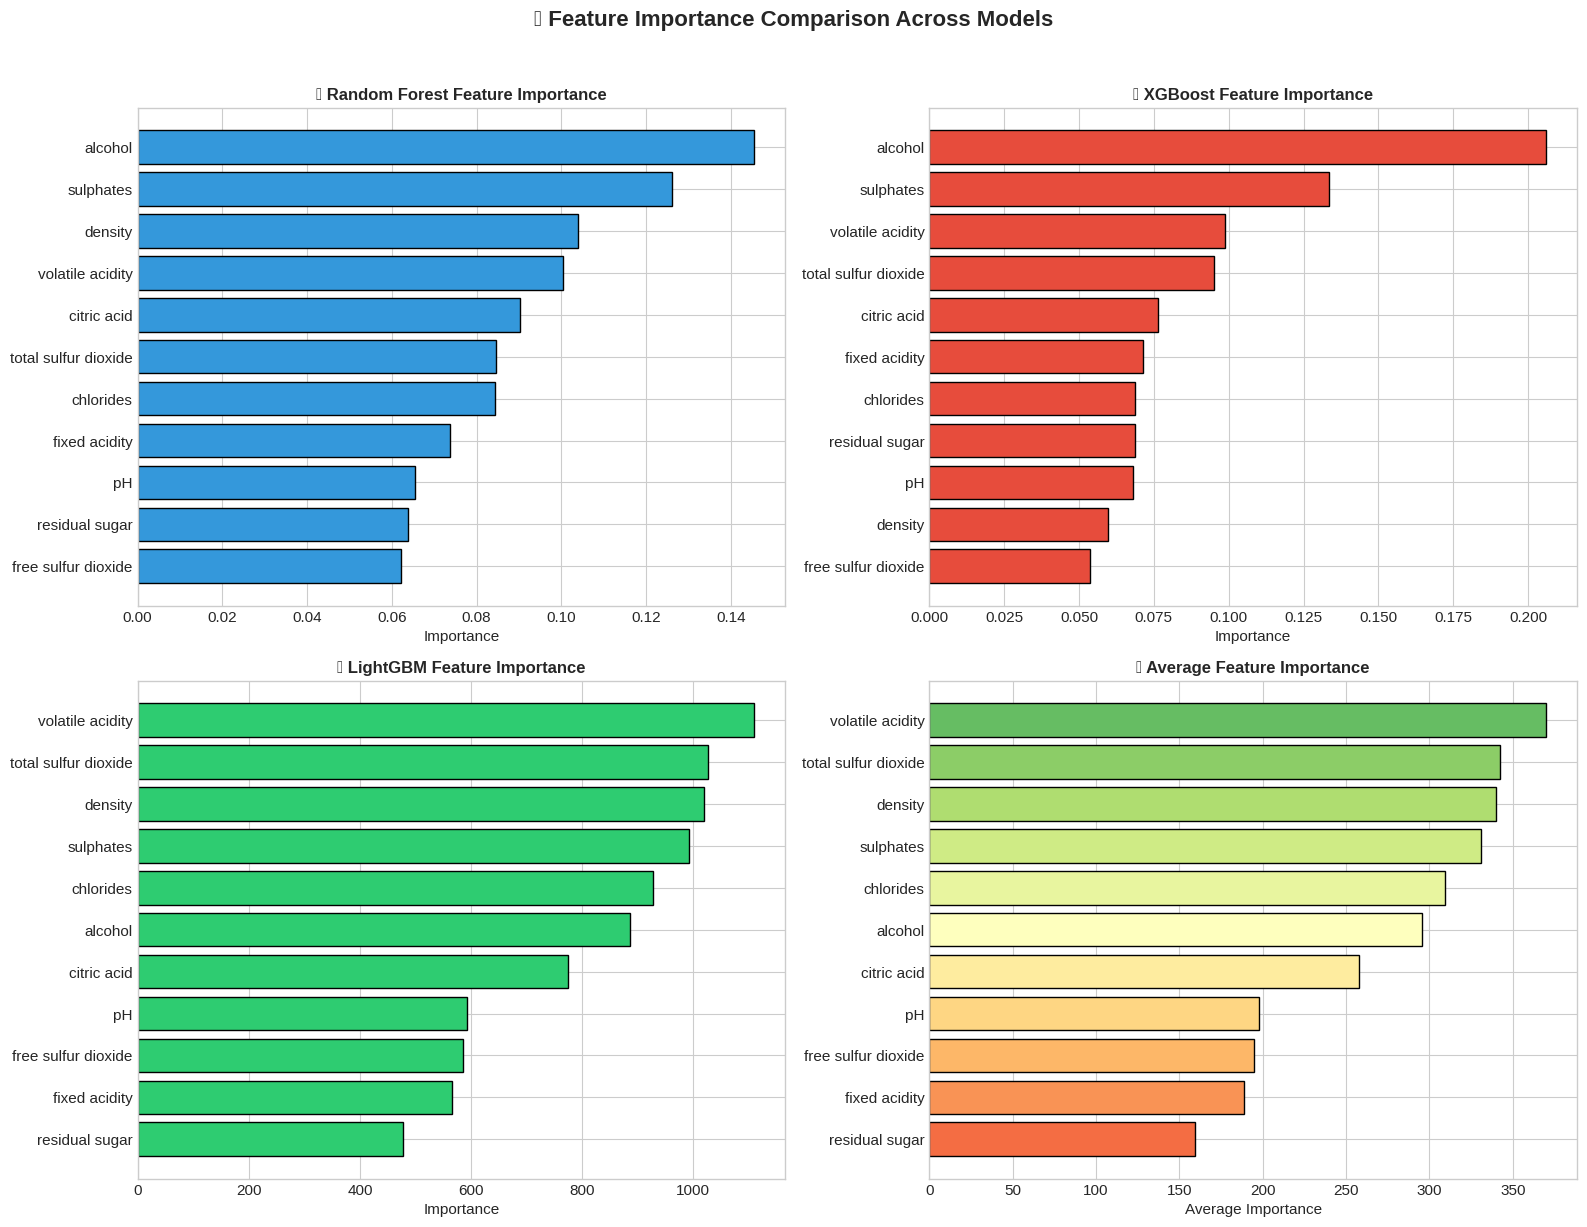

In [35]:
# Visualize Feature Importance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Random Forest
ax1 = axes[0, 0]
importance_sorted = importance_df.sort_values('Random Forest', ascending=True)
ax1.barh(importance_sorted['Feature'], importance_sorted['Random Forest'], color='#3498db', edgecolor='black')
ax1.set_xlabel('Importance')
ax1.set_title('🌲 Random Forest Feature Importance', fontsize=12, fontweight='bold')

# XGBoost
ax2 = axes[0, 1]
importance_sorted = importance_df.sort_values('XGBoost', ascending=True)
ax2.barh(importance_sorted['Feature'], importance_sorted['XGBoost'], color='#e74c3c', edgecolor='black')
ax2.set_xlabel('Importance')
ax2.set_title('🚀 XGBoost Feature Importance', fontsize=12, fontweight='bold')

# LightGBM
ax3 = axes[1, 0]
importance_sorted = importance_df.sort_values('LightGBM', ascending=True)
ax3.barh(importance_sorted['Feature'], importance_sorted['LightGBM'], color='#2ecc71', edgecolor='black')
ax3.set_xlabel('Importance')
ax3.set_title('💡 LightGBM Feature Importance', fontsize=12, fontweight='bold')

# Average
ax4 = axes[1, 1]
importance_sorted = importance_df.sort_values('Average', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_sorted)))
ax4.barh(importance_sorted['Feature'], importance_sorted['Average'], color=colors, edgecolor='black')
ax4.set_xlabel('Average Importance')
ax4.set_title('📊 Average Feature Importance', fontsize=12, fontweight='bold')

plt.suptitle('🔍 Feature Importance Comparison Across Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

📊 Permutation Importance Analysis

📋 Permutation Importance (Random Forest):
             Feature  Importance Mean  Importance Std
             alcohol           0.0213          0.0093
           sulphates           0.0178          0.0092
total sulfur dioxide           0.0137          0.0064
             density           0.0102          0.0064
           chlorides           0.0102          0.0039
 free sulfur dioxide           0.0051          0.0032
       fixed acidity           0.0046          0.0048
                  pH           0.0046          0.0036
    volatile acidity           0.0000          0.0064
      residual sugar          -0.0020          0.0052
         citric acid          -0.0025          0.0034


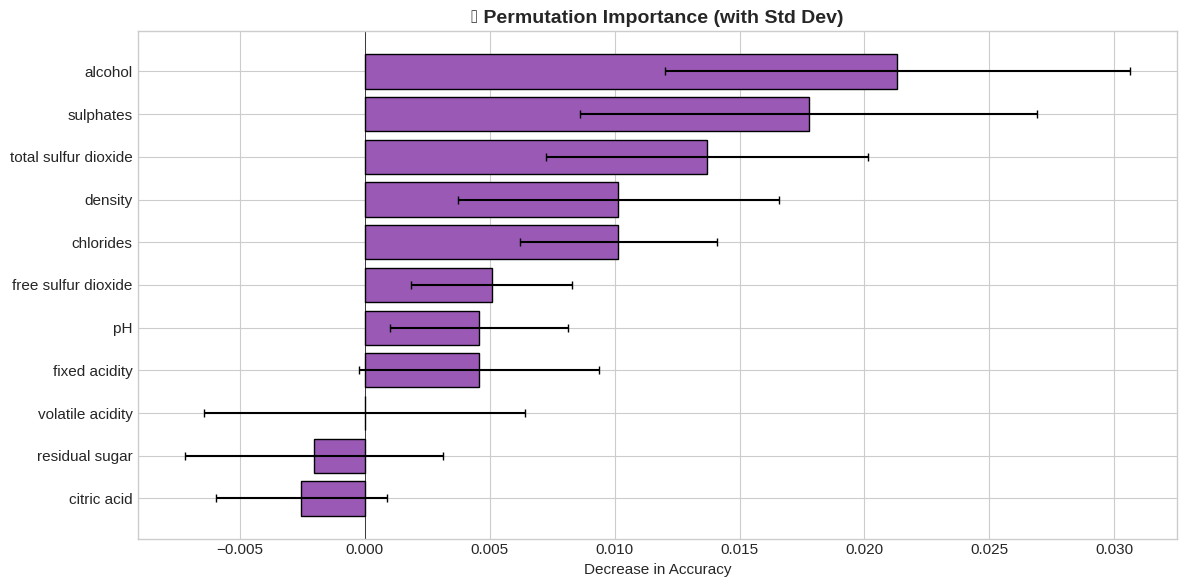

In [36]:
# Permutation Importance
from sklearn.inspection import permutation_importance

print("📊 Permutation Importance Analysis")
print("=" * 60)

# Calculate permutation importance
perm_importance = permutation_importance(
    rf_model, X_test_multi_scaled, y_test_multi,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values('Importance Mean', ascending=False)

print("\n📋 Permutation Importance (Random Forest):")
print(perm_imp_df.round(4).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
perm_imp_sorted = perm_imp_df.sort_values('Importance Mean', ascending=True)

ax.barh(perm_imp_sorted['Feature'], perm_imp_sorted['Importance Mean'],
        xerr=perm_imp_sorted['Importance Std'], color='#9b59b6', edgecolor='black', capsize=3)
ax.set_xlabel('Decrease in Accuracy')
ax.set_title('📊 Permutation Importance (with Std Dev)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

📊 SHAP Analysis


<Figure size 1200x800 with 0 Axes>

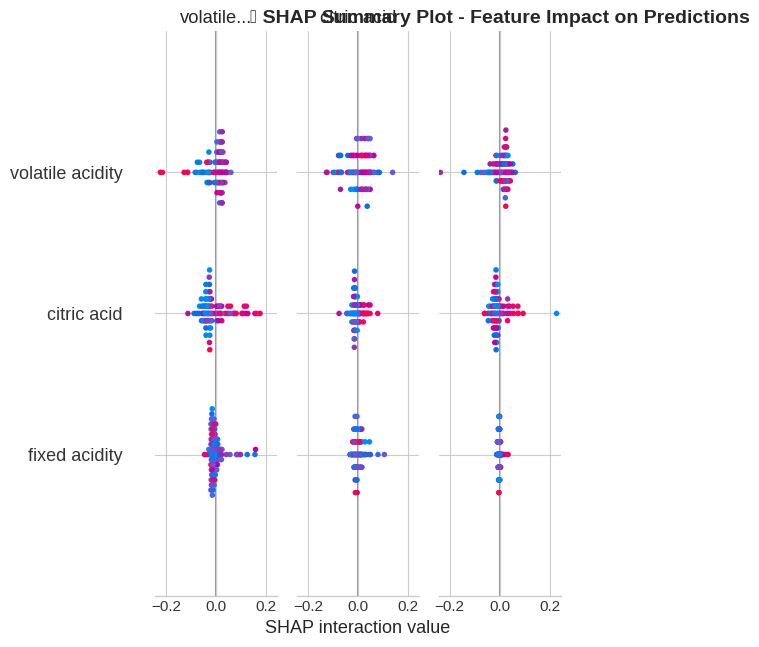

In [37]:
# SHAP Values (if time permits)
print("📊 SHAP Analysis")
print("=" * 60)

!pip install shap -q
import shap

# Use a smaller sample for SHAP (faster computation)
X_sample = X_test_multi_scaled[:100]

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  class_names=['Low', 'Medium', 'High'], show=False)
plt.title('📊 SHAP Summary Plot - Feature Impact on Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Final Model & Predictions

In [38]:
# Select and train final model
print("🏆 Final Model Selection")
print("=" * 60)

# Use the best tuned model (or best performing model)
final_model = rf_grid.best_estimator_  # or choose based on results

# Train on full training data
final_model.fit(X_train_multi_scaled, y_train_multi)

# Final predictions
y_final_pred = final_model.predict(X_test_multi_scaled)

# Final metrics
print(f"\n📊 Final Model: {type(final_model).__name__}")
print(f"   Best Parameters: {rf_grid.best_params_}")
print(f"\n📈 Final Test Set Performance:")
print(f"   Accuracy: {accuracy_score(y_test_multi, y_final_pred):.4f}")
print(f"   Precision: {precision_score(y_test_multi, y_final_pred, average='weighted'):.4f}")
print(f"   Recall: {recall_score(y_test_multi, y_final_pred, average='weighted'):.4f}")
print(f"   F1-Score: {f1_score(y_test_multi, y_final_pred, average='weighted'):.4f}")

🏆 Final Model Selection

📊 Final Model: RandomForestClassifier
   Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5}

📈 Final Test Set Performance:
   Accuracy: 0.8782
   Precision: 0.8488
   Recall: 0.8782
   F1-Score: 0.8457


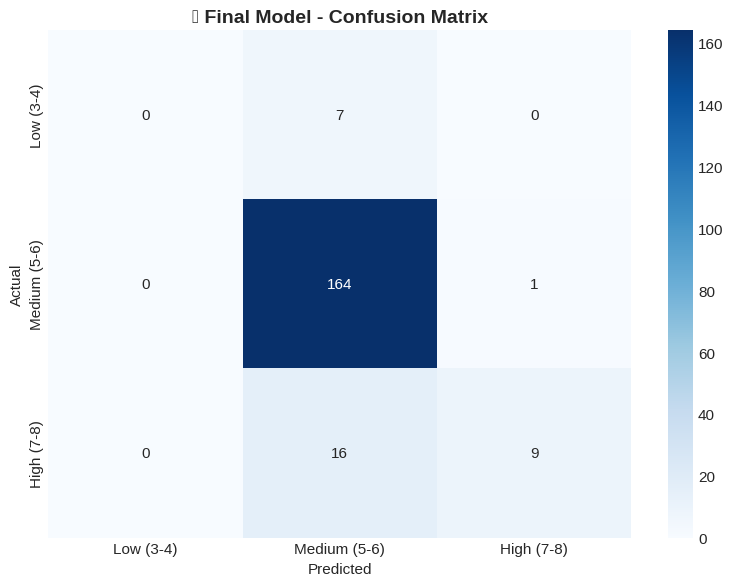


📋 Final Classification Report:
              precision    recall  f1-score   support

   Low (3-4)       0.00      0.00      0.00         7
Medium (5-6)       0.88      0.99      0.93       165
  High (7-8)       0.90      0.36      0.51        25

    accuracy                           0.88       197
   macro avg       0.59      0.45      0.48       197
weighted avg       0.85      0.88      0.85       197



In [39]:
# Final Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test_multi, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low (3-4)', 'Medium (5-6)', 'High (7-8)'],
            yticklabels=['Low (3-4)', 'Medium (5-6)', 'High (7-8)'])
ax.set_title('🏆 Final Model - Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Classification Report
print("\n📋 Final Classification Report:")
print("=" * 60)
print(classification_report(y_test_multi, y_final_pred,
                            target_names=['Low (3-4)', 'Medium (5-6)', 'High (7-8)']))

In [40]:
# Sample Predictions
print("📋 Sample Predictions:")
print("=" * 60)

# Get sample predictions
sample_indices = np.random.choice(len(X_test_multi), size=10, replace=False)

quality_map = {0: 'Low (3-4)', 1: 'Medium (5-6)', 2: 'High (7-8)'}

sample_df = pd.DataFrame({
    'Actual': [quality_map[y_test_multi.iloc[i]] for i in sample_indices],
    'Predicted': [quality_map[y_final_pred[i]] for i in sample_indices],
    'Correct': [y_test_multi.iloc[i] == y_final_pred[i] for i in sample_indices]
})

print(sample_df.to_string(index=False))
print(f"\nAccuracy on sample: {sample_df['Correct'].mean()*100:.1f}%")

📋 Sample Predictions:
      Actual    Predicted  Correct
Medium (5-6) Medium (5-6)     True
Medium (5-6) Medium (5-6)     True
Medium (5-6) Medium (5-6)     True
Medium (5-6) Medium (5-6)     True
  High (7-8) Medium (5-6)    False
Medium (5-6) Medium (5-6)     True
Medium (5-6) Medium (5-6)     True
Medium (5-6) Medium (5-6)     True
  High (7-8)   High (7-8)     True
Medium (5-6) Medium (5-6)     True

Accuracy on sample: 90.0%


In [41]:
# Save the final model
import pickle

# Save model
model_path = '/content/drive/My Drive/Wine Quality/final_wine_quality_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)

# Save scaler
scaler_path = '/content/drive/My Drive/Wine Quality/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler_multi, f)

print(f"✅ Model saved to: {model_path}")
print(f"✅ Scaler saved to: {scaler_path}")

✅ Model saved to: /content/drive/My Drive/Wine Quality/final_wine_quality_model.pkl
✅ Scaler saved to: /content/drive/My Drive/Wine Quality/scaler.pkl


---
## 10. Conclusions & Recommendations

In [42]:
# Final Summary Dashboard
print("="*80)
print("🍷 VINO VERITAS - MACHINE LEARNING ANALYSIS SUMMARY")
print("="*80)

print("\n📊 DATASET SUMMARY:")
print("-"*50)
print(f"   • Total samples: {len(df)}")
print(f"   • Features: {len(X.columns)}")
print(f"   • Target: Wine Quality (3-8)")

print("\n🏆 BEST PERFORMING MODELS:")
print("-"*50)
print(f"   Classification (Binary):")
print(f"     • {binary_results.iloc[0]['Model']}: F1={binary_results.iloc[0]['F1-Score']:.4f}")
print(f"   Classification (Multi-Class):")
print(f"     • {multi_results.iloc[0]['Model']}: F1={multi_results.iloc[0]['F1-Score']:.4f}")
print(f"   Regression:")
print(f"     • {regression_results.iloc[0]['Model']}: R2={regression_results.iloc[0]['R2 Score']:.4f}")

print("\n🔍 KEY FEATURES (by importance):")
print("-"*50)
for i, row in importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Average']:.4f}")

print("\n✅ RECOMMENDATIONS FOR VINO VERITAS:")
print("-"*50)
print("")
print("   1. FOCUS ON KEY QUALITY DRIVERS:")
top_features_list = importance_df.head(3)['Feature'].tolist()
for feat in top_features_list:
    print(f"      • {feat}")
print("")
print("   2. MODEL DEPLOYMENT:")
print(f"      • Use {type(final_model).__name__} for quality prediction")
print(f"      • Expected accuracy: ~{accuracy_score(y_test_multi, y_final_pred)*100:.1f}%")
print("")
print("   3. QUALITY IMPROVEMENT STRATEGIES:")
print("      • Optimize alcohol content for premium wines")
print("      • Minimize volatile acidity through controlled fermentation")
print("      • Monitor sulphate levels for quality consistency")
print("")
print("   4. CONTINUOUS MONITORING:")
print("      • Implement the model in production pipeline")
print("      • Retrain periodically with new data")
print("      • Track feature drift over time")

print("\n" + "="*80)
print("END OF MACHINE LEARNING ANALYSIS")
print("="*80)

🍷 VINO VERITAS - MACHINE LEARNING ANALYSIS SUMMARY

📊 DATASET SUMMARY:
--------------------------------------------------
   • Total samples: 985
   • Features: 11
   • Target: Wine Quality (3-8)

🏆 BEST PERFORMING MODELS:
--------------------------------------------------
   Classification (Binary):
     • XGBoost: F1=0.8989
   Classification (Multi-Class):
     • Logistic Regression: F1=0.8581
   Regression:
     • Extra Trees: R2=0.4561

🔍 KEY FEATURES (by importance):
--------------------------------------------------
   1. volatile acidity: 370.0663
   2. total sulfur dioxide: 342.3932
   3. density: 339.7213
   4. sulphates: 330.7532
   5. chlorides: 309.3844

✅ RECOMMENDATIONS FOR VINO VERITAS:
--------------------------------------------------

   1. FOCUS ON KEY QUALITY DRIVERS:
      • volatile acidity
      • total sulfur dioxide
      • density

   2. MODEL DEPLOYMENT:
      • Use RandomForestClassifier for quality prediction
      • Expected accuracy: ~87.8%

   3. QUALITY

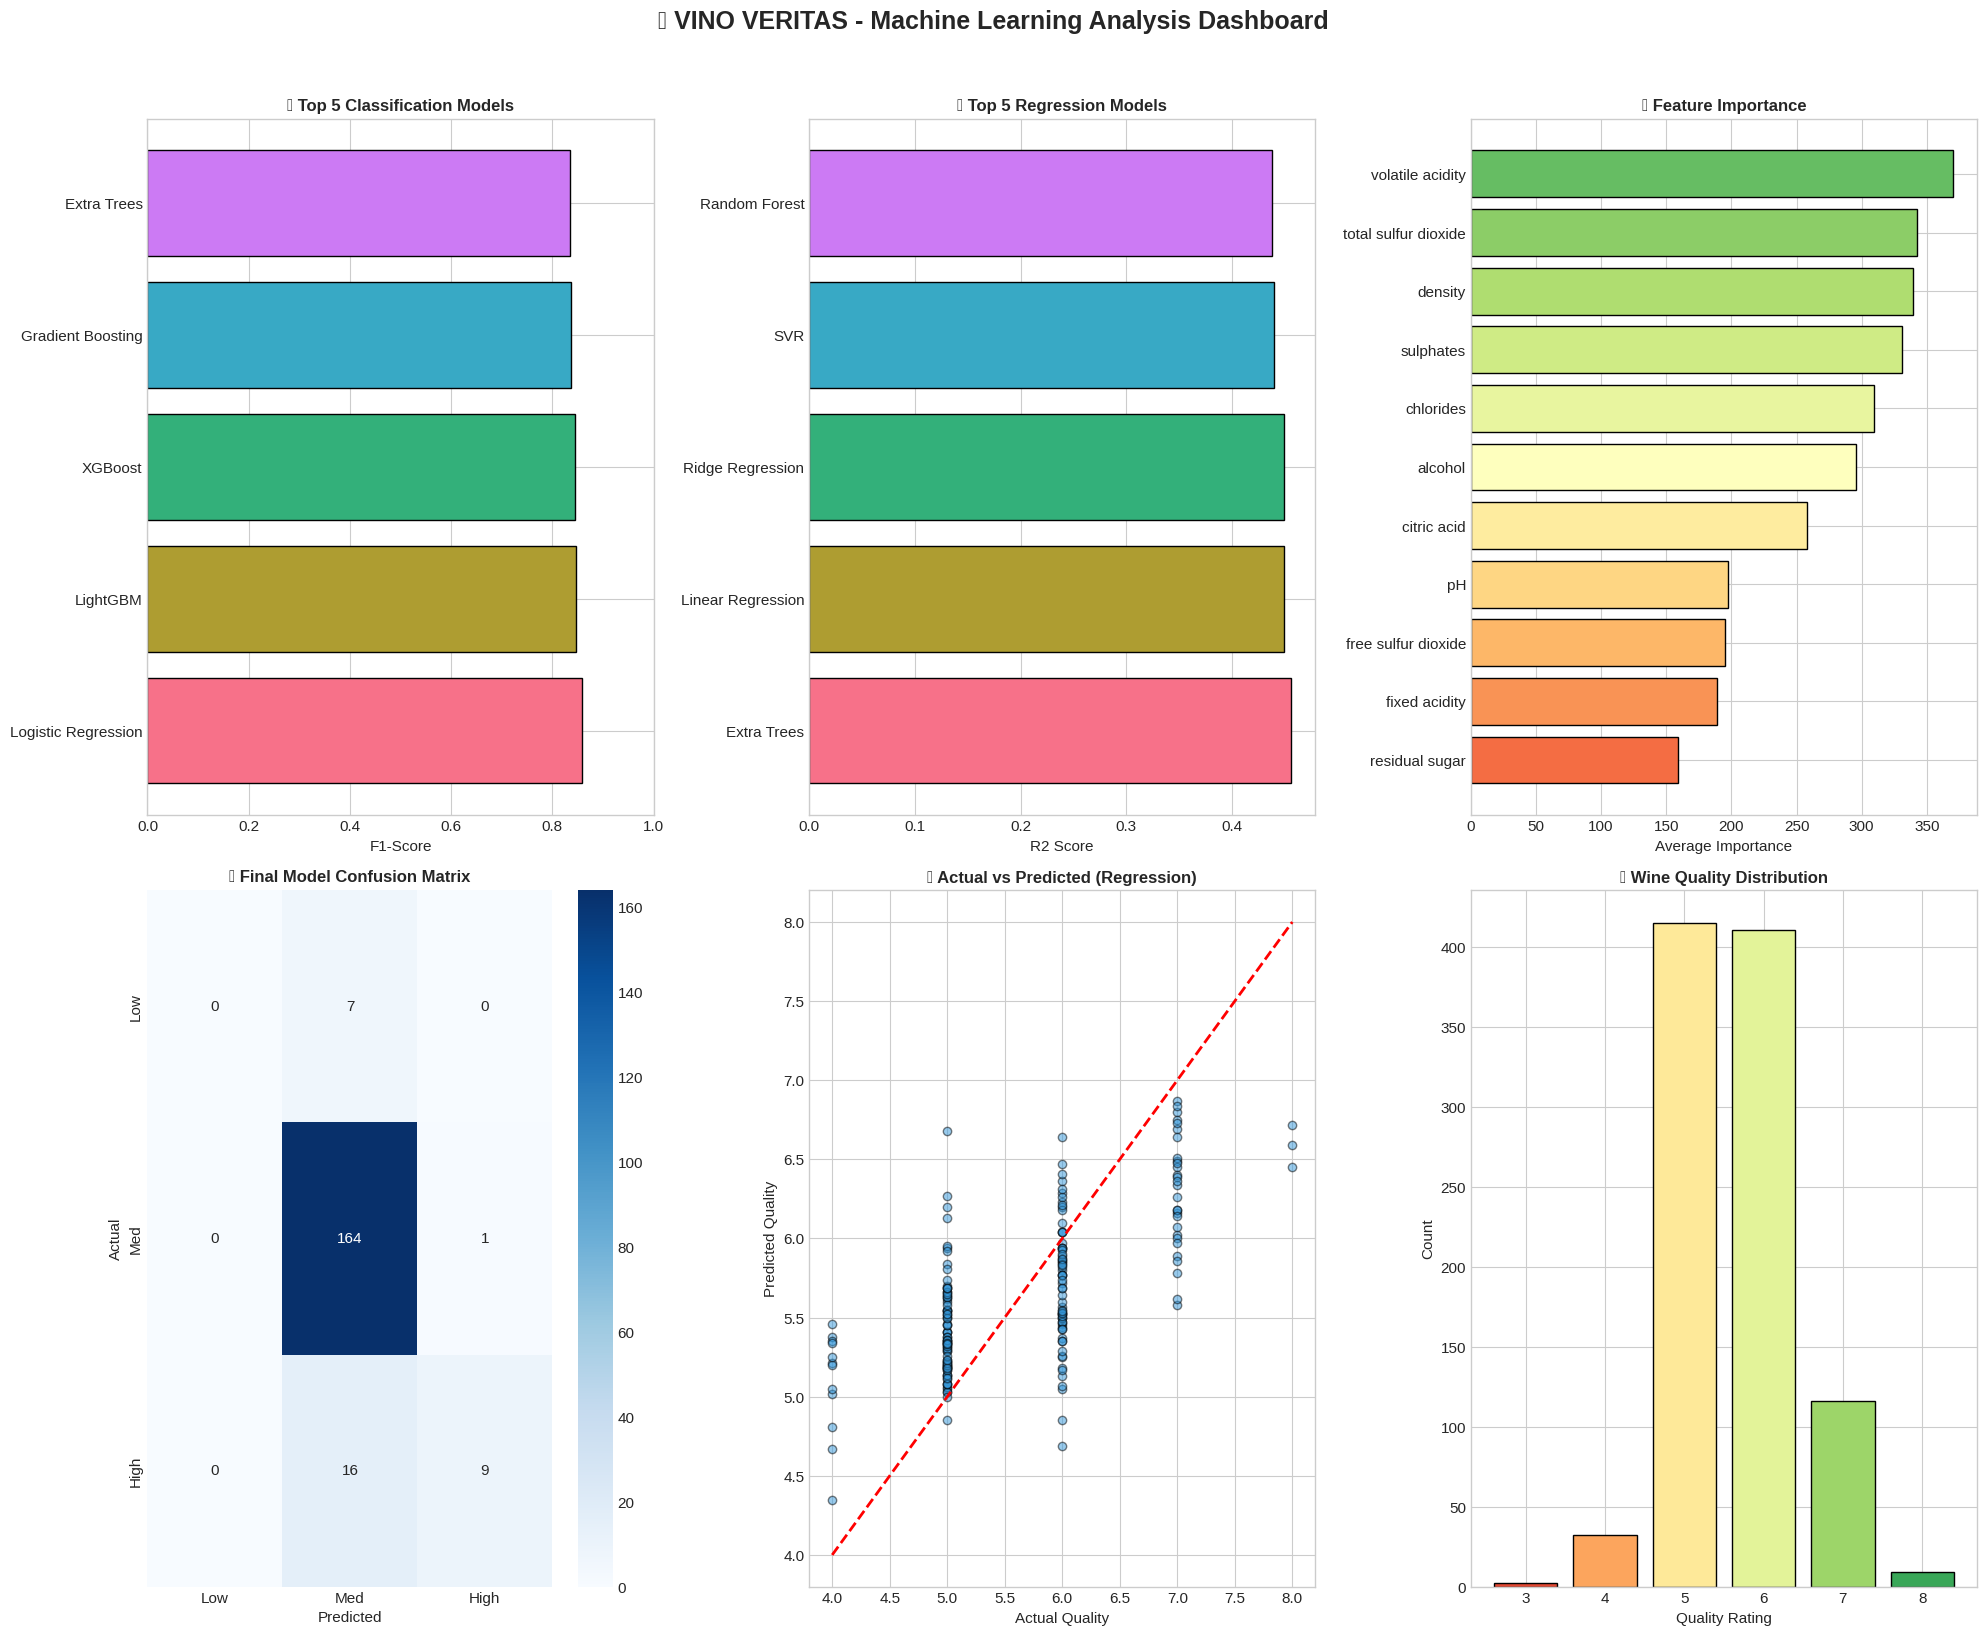


✅ Machine Learning Analysis Complete!


In [43]:
# Create Summary Visualization Dashboard
fig = plt.figure(figsize=(20, 16))

# 1. Model Comparison - Classification
ax1 = fig.add_subplot(2, 3, 1)
top5_class = multi_results.head(5)
ax1.barh(top5_class['Model'], top5_class['F1-Score'], color=sns.color_palette('husl', 5), edgecolor='black')
ax1.set_xlabel('F1-Score')
ax1.set_title('🎯 Top 5 Classification Models', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1)

# 2. Model Comparison - Regression
ax2 = fig.add_subplot(2, 3, 2)
top5_reg = regression_results.head(5)
ax2.barh(top5_reg['Model'], top5_reg['R2 Score'], color=sns.color_palette('husl', 5), edgecolor='black')
ax2.set_xlabel('R2 Score')
ax2.set_title('📈 Top 5 Regression Models', fontsize=12, fontweight='bold')

# 3. Feature Importance
ax3 = fig.add_subplot(2, 3, 3)
imp_sorted = importance_df.sort_values('Average', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(imp_sorted)))
ax3.barh(imp_sorted['Feature'], imp_sorted['Average'], color=colors, edgecolor='black')
ax3.set_xlabel('Average Importance')
ax3.set_title('🔍 Feature Importance', fontsize=12, fontweight='bold')

# 4. Confusion Matrix
ax4 = fig.add_subplot(2, 3, 4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Low', 'Med', 'High'],
            yticklabels=['Low', 'Med', 'High'])
ax4.set_title('📊 Final Model Confusion Matrix', fontsize=12, fontweight='bold')
ax4.set_ylabel('Actual')
ax4.set_xlabel('Predicted')

# 5. Actual vs Predicted (Regression)
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='#3498db', edgecolor='black')
ax5.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
         'r--', linewidth=2)
ax5.set_xlabel('Actual Quality')
ax5.set_ylabel('Predicted Quality')
ax5.set_title('📈 Actual vs Predicted (Regression)', fontsize=12, fontweight='bold')

# 6. Quality Distribution
ax6 = fig.add_subplot(2, 3, 6)
quality_counts = df['quality'].value_counts().sort_index()
colors = sns.color_palette('RdYlGn', n_colors=len(quality_counts))
ax6.bar(quality_counts.index.astype(str), quality_counts.values, color=colors, edgecolor='black')
ax6.set_xlabel('Quality Rating')
ax6.set_ylabel('Count')
ax6.set_title('🍷 Wine Quality Distribution', fontsize=12, fontweight='bold')

plt.suptitle('🍷 VINO VERITAS - Machine Learning Analysis Dashboard',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Machine Learning Analysis Complete!")